# LADDER + TTRL — Stage-0 validation (notebook-bound)

**Question this notebook answers:** *Does LADDER-style re-rooting + test-time adaptation
crack a level the current BFS agent cannot — on the real games `ls20` and `ar25`?*

This is **Stage 0** of `LADDER_PLAN.md`: a cheap, honest validation of the lever
**before** any change to the shipped agent. We only **import** `combined_agent`
(the v13/v17 BFS ladder) — we change *no* agent code.

### The idea (LADDER, Tufa Labs · arXiv:2503.00735), instantiated for ARC-AGI-3
- **Verifier** = the engine's `levels_completed` (cheap to check, hard to solve).
- **Variant generation** = re-root the hard level at **BFS progress-landmarks**
  (states *closer to the goal*, reached by cheap rollouts on the **forked** engine).
  High-progress landmarks are *easier sub-variants* — LADDER's "tree of simpler
  variants" for a deterministic game.
- **TTRL adaptation** = finish each variant (easiest first) with a short BFS, then
  **chain** prefix(→landmark) + suffix(→goal) and **verify**. All of this runs on a
  **forked simulator**, so on Kaggle it costs **zero scored actions** (free under RHAE).
- We also include a compact **GRPO-lite** cell (the literal RL mechanic) — honestly
  labelled, since for a deterministic game the re-rooting search is the stronger lever.

### Honest contract
- **No stored answers.** `V19_STORE_SOLUTIONS=0`, `V19_CACHE_FALLBACK=0` (same as the
  `test_ls20.py` gate). The baseline genuinely searches; LADDER genuinely searches.
- The success metric is binary and unforgiving: **did LADDER clear a level the BFS
  baseline could not, in comparable budget?** A *no* is a real result too — it tells
  us the wall is deeper than re-rooting alone and points to Stage-1 (full GRPO with a
  state-conditioned policy).

### Reference
Tufa Labs' own code (LLM/integration domain, *pattern* not code reused here):
`git clone https://github.com/Tufalabs/LADDER`. Their variant generation is LLM-prompted
+ numerically verified; ours is engine-native + `levels_completed`-verified.

In [1]:
# === Setup — import the shipped agent (no agent code changes), honest mode ON ===
import os, sys, glob, re, time, json, pickle, zlib, copy, hashlib, random
from collections import deque
import numpy as np

os.environ["V19_STORE_SOLUTIONS"] = "0"   # never write a cache
os.environ["V19_CACHE_FALLBACK"]  = "0"   # never read a cache  -> genuine search only

# --- robustly locate v19/src (holds combined_agent.py) from ANYWHERE -----------
def _locate_src():
    here = os.getcwd()
    cands = [os.path.join(here, "src"), here, os.path.join(here, "..", "src"),
             os.path.join(os.path.dirname(here), "src")]
    for base in [os.environ.get("V19_DIR", ""),
                 "/Users/shreyas/gitrepos/OpenSource/kaggle/arc3/CommunitySolutions/chronos_solver/v19",
                 "/workspace/arc3/CommunitySolutions/chronos_solver/v19",
                 "/kaggle/working/arc3/CommunitySolutions/chronos_solver/v19"]:
        if base:
            cands += [os.path.join(base, "src"), base]
    for c in cands:
        if c and os.path.isfile(os.path.join(c, "combined_agent.py")):
            return os.path.abspath(c)
    for root in [here, os.path.dirname(here), "/workspace", "/kaggle", os.path.expanduser("~")]:
        if root and os.path.isdir(root):
            hits = glob.glob(os.path.join(root, "**", "v19", "src", "combined_agent.py"), recursive=True)
            if hits:
                return os.path.dirname(hits[0])
    raise FileNotFoundError("combined_agent.py not found — set env V19_DIR to the v19 folder")

SRC = _locate_src()
sys.path.insert(0, SRC)

def _find_env_dir(start):
    d = start
    for _ in range(8):
        cand = os.path.join(d, "arc-prize-2026-arc-agi-3", "environment_files")
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    for base in [os.path.dirname(start), "/workspace", "/kaggle/input", os.path.expanduser("~")]:
        if base and os.path.isdir(base):
            hits = glob.glob(os.path.join(base, "**", "environment_files"), recursive=True)
            if hits:
                return hits[0]
    return os.path.join(start, "..", "..", "..", "..", "arc-prize-2026-arc-agi-3", "environment_files")

ENV_DIR = _find_env_dir(SRC)

from combined_agent import BFSSolver
try:
    from combined_agent import ActionInput, GameAction
except Exception:
    from arcengine import GameAction
    try:    from arcengine import ActionInput
    except Exception: from combined_agent import ActionInput

random.seed(0); np.random.seed(0)
print("src dir  :", SRC)
print("env_files:", ENV_DIR, "| exists:", os.path.isdir(ENV_DIR))
print("honest mode: STORE=%s CACHE=%s" % (os.environ['V19_STORE_SOLUTIONS'], os.environ['V19_CACHE_FALLBACK']))

src dir  : /Users/shreyas/gitrepos/OpenSource/kaggle/arc3/CommunitySolutions/chronos_solver/v19/src
env_files: /Users/shreyas/gitrepos/OpenSource/kaggle/arc3/arc-prize-2026-arc-agi-3/environment_files | exists: True
honest mode: STORE=0 CACHE=0


## 1 · Engine driver (white-box, identical calls to the agent)

A thin wrapper over the shipped game class + `BFSSolver`'s helpers, so every action
we take drives the engine *exactly* as the live agent would. `snap`/`restore` fork the
simulator (this is what makes TTRL free under RHAE). `goal()` is the verifier.

In [2]:
def resolve_game(gid):
    src = glob.glob(os.path.join(ENV_DIR, gid, "**", f"{gid}.py"), recursive=True)
    assert src, f"no source for {gid} under {ENV_DIR}"
    src = src[0]
    txt = open(src).read()
    m = re.search(r"class\s+(\w+)\s*\(\s*ARCBaseGame", txt)   # robust class detection
    cls = m.group(1) if m else (gid[0].upper() + gid[1:])
    return src, cls

def snap(g):
    try:    return ("p", zlib.compress(pickle.dumps(g, -1), 1))
    except Exception: return ("d", copy.deepcopy(g))
def restore(s):
    k, p = s
    return pickle.loads(zlib.decompress(p)) if k == "p" else copy.deepcopy(p)
def fsig(f):  # frame signature (dedup + novelty)
    return hashlib.md5(np.ascontiguousarray(f).tobytes()).hexdigest()[:16]

class Engine:
    # white-box driver over the shipped game class
    def __init__(self, gid, budget=120):
        self.gid = gid
        self.src, self.cls_name = resolve_game(gid)
        self.solver = BFSSolver(self.src, self.cls_name, bfs_timeout=budget)
        assert self.solver.load(), f"failed to load game class for {gid}"
        self.game_cls  = self.solver.game_cls
        self.num_levels = len(self.game_cls()._levels)
    def fresh(self, level):
        g = self.game_cls(); g.set_level(level)
        g.perform_action(ActionInput(id=GameAction.RESET), raw=True)
        r = g.perform_action(ActionInput(id=GameAction.RESET), raw=True)
        return g, np.array(r.frame[-1])
    def step(self, g, a, d=None):
        ai = ActionInput(id=GameAction.from_id(a), data=d) if d else ActionInput(id=GameAction.from_id(a))
        return g.perform_action(ai, raw=True)
    @staticmethod
    def frame(r):  return np.array(r.frame[-1]) if (r and r.frame) else None
    @staticmethod
    def goal(g, r, level):     # the VERIFIER
        return bool(getattr(r, "levels_completed", 0) > level or
                    getattr(g, "_current_level_index", 0) > level)
    def scan(self, g, f0):     # effective actions (incl. shape-aware clicks)
        bg = int(np.bincount(f0.flatten(), minlength=16).argmax())
        return self.solver._scan_actions(g, f0, bg)

# smoke check
_e = Engine("ls20"); print("ls20:", _e.num_levels, "levels, class", _e.cls_name)

ls20: 7 levels, class Ls20


## 2 · Baseline = the current agent

`solver.solve_level(lvl, strategy="auto")` runs the **full v13 ladder** (masked BFS →
waypoint → A* → IW → greedy → rescues), chaining each level from the genuinely-solved
prior ones. We march L0, L1, … on a fixed per-level budget and stop at the first level
it can't clear — **the wall**. That wall is exactly what LADDER must beat.

In [3]:
def run_baseline(gid, per_level_budget=120, max_levels=None):
    eng = Engine(gid, budget=per_level_budget)
    N = eng.num_levels if max_levels is None else min(max_levels, eng.num_levels)
    solved, per_level, wall = [], {}, None
    for lvl in range(N):
        t = time.time()
        sol = eng.solver.solve_level(lvl, strategy="auto")
        dt = time.time() - t
        if sol:
            eng.solver.solutions[lvl] = sol          # enables TRUE chained start for next level
            solved.append(lvl)
            per_level[lvl] = {"actions": len(sol), "secs": dt, "solved": True}
            print(f"  [BFS] L{lvl}: solved in {len(sol)} actions ({dt:.0f}s)")
        else:
            per_level[lvl] = {"actions": None, "secs": dt, "solved": False}
            print(f"  [BFS] L{lvl}: WALL — unsolved in {dt:.0f}s")
            wall = lvl; break
    return {"gid": gid, "num_levels": N, "solved": solved, "wall": wall,
            "per_level": per_level, "engine": eng}

## 3 · LADDER variant generation + TTRL adaptation

**`collect_landmarks`** — from the wall level's *true chained start*, run cheap random
rollouts on the **forked** engine and bank every reachable state, ranked by **progress**
(order of first discovery = frame-novelty). High-progress landmarks sit *near the goal*:
they are the **easier variants**.

**`bfs_from`** — a short BFS from a (re-rooted) landmark snapshot to the goal: the
"solve the easier variant" step.

**`ladder_solve`** — the **TTRL loop**: try the easiest variants first; the first one
whose suffix BFS reaches the goal gives `prefix(→landmark) + suffix(→goal)`, which we
**chain after the genuinely-solved prior levels and verify on a fresh engine**. All
forked-engine compute → **zero scored actions**.

In [4]:
def hist_sig(f):   # colour-histogram = meaningful state (tracks keys/doors, not player-wander)
    return tuple(np.bincount(np.ascontiguousarray(f).flatten(), minlength=16).tolist())

def collect_landmarks(eng, level, prev_solutions, n_iters=2000, chunk=4, depth_cap=400):
    # LADDER variant tree, GO-EXPLORE style (the right deterministic-game instantiation):
    # archive promising cells (keyed by colour histogram), then repeatedly RE-ROOT at a
    # DEEP + rarely-visited cell and explore further. The deepest reachable cells are the
    # states nearest the goal -> the easiest sub-variants to finish with a short BFS.
    eng.solver.solutions.update(prev_solutions)              # for the TRUE chained start
    start = eng.solver._make_start_state(level)
    g, f0 = start if start is not None else eng.fresh(level)
    base_snap = snap(g)
    cand = eng.scan(g, f0)
    if not cand:
        return [], f0, base_snap, cand
    # cell -> [depth(=path len), snap, path, frame, visits]
    archive = {hist_sig(f0): [0, base_snap, [], f0, 0]}
    goal_path = None
    for _ in range(n_iters):
        cells = list(archive.values())
        w = np.array([(c[0] + 1.0) / (c[4] + 1.0) for c in cells], dtype=float)  # deep + unvisited
        w /= w.sum()
        c = cells[int(np.random.choice(len(cells), p=w))]
        c[4] += 1
        gg = restore(c[1]); path = list(c[2])
        for _ in range(chunk):
            if len(path) >= depth_cap:
                break
            a, dd = random.choice(cand)
            r = eng.step(gg, a, dd); path.append((a, dd))
            f = eng.frame(r)
            if f is None:
                break
            if eng.goal(gg, r, level):
                goal_path = list(path); break
            s = hist_sig(f)
            prev = archive.get(s)
            if prev is None or len(path) > prev[0]:          # keep the DEEPEST representative
                archive[s] = [len(path), snap(gg), list(path), f, 0 if prev is None else prev[4]]
        if goal_path is not None:
            break
    ranked = [tuple(c[:4]) for c in sorted(archive.values(), key=lambda x: -x[0])]  # deepest first
    if goal_path is not None:
        ranked = [(10**9, None, goal_path, None)] + ranked
    return ranked, f0, base_snap, cand

def bfs_from(eng, start_snap, f0, level, cand, budget=45, max_states=2000000):
    t0 = time.time()
    q = deque([(start_snap, [])])
    seen = {fsig(f0)}; states = 0
    while q and (time.time() - t0) < budget and states < max_states:
        sn, path = q.popleft()
        for a, d in cand:
            g = restore(sn)
            r = eng.step(g, a, d); states += 1
            f = eng.frame(r)
            if f is None:
                continue
            if eng.goal(g, r, level):
                return path + [(a, d)], states, time.time() - t0
            s = fsig(f)
            if s in seen:
                continue
            seen.add(s)
            q.append((snap(g), path + [(a, d)]))
    return None, states, time.time() - t0

def verify(eng, level, full_path, prev_solutions):
    g = eng.game_cls()
    g.perform_action(ActionInput(id=GameAction.RESET), raw=True)
    g.perform_action(ActionInput(id=GameAction.RESET), raw=True)
    for li in range(level):
        for a, d in prev_solutions[li]:
            eng.step(g, a, d)
    r = None
    for a, d in full_path:
        r = eng.step(g, a, d)
    return eng.goal(g, r, level)

def ladder_solve(eng, level, prev_solutions, n_variants=12, variant_budget=45,
                 ge_iters=2500, ge_chunk=4, verbose=True):
    ranked, f0, base_snap, cand = collect_landmarks(eng, level, prev_solutions,
                                                     n_iters=ge_iters, chunk=ge_chunk)
    if not cand:
        return None, {"via": None, "reason": "no effective actions", "log": []}
    log = []
    # (a) exploration may have already reached the goal
    for prog, sn, path, frm in ranked:
        if prog >= 10**8:
            if verify(eng, level, path, prev_solutions):
                return path, {"via": "explore", "actions": len(path), "log": log}
    # (b) re-root at the deepest (nearest-goal) landmarks, finish with a short BFS
    for i, (prog, sn, path, frm) in enumerate(x for x in ranked[:n_variants] if x[1] is not None):
        suffix, states, dt = bfs_from(eng, sn, frm, level, cand, budget=variant_budget, max_states=1000000)
        rec = {"rank": i, "landmark_progress": int(prog), "prefix_len": len(path),
               "suffix_found": suffix is not None, "bfs_states": states, "secs": round(dt, 1)}
        log.append(rec)
        if verbose:
            print(f"    variant#{i} (progress {prog}, prefix {len(path)}): "
                  f"{'SUFFIX FOUND ' + str(len(suffix)) + 'a' if suffix else 'no suffix'} "
                  f"[{states} states, {dt:.0f}s]")
        if suffix is not None:
            full = path + suffix
            if verify(eng, level, full, prev_solutions):
                return full, {"via": "re-root", "actions": len(full),
                              "prefix": len(path), "suffix": len(suffix), "log": log}
    return None, {"via": None, "variants_tried": len(ranked[:n_variants]), "log": log}

## 4 · (optional) GRPO-lite — the literal RL/TTRL mechanic

A compact **group-relative policy gradient**: a softmax policy over the scanned actions,
adapted by `advantage = reward − group_mean` on the forked engine, reward = shaped
progress (novel frames) + big goal bonus. This demonstrates the GRPO loop end-to-end.

**Honest caveat:** this toy policy is *state-light* (a per-step action prior), so it is
**not expected to crack hard levels** — that needs a state-conditioned net (Stage 1).
It's here to show the exact RL move that Stage 1/2 scales up. Skip if you only want the
re-rooting result.

In [5]:
def grpo_lite(eng, level, prev_solutions, iters=30, group=24, horizon=120, lr=0.6, verbose=True):
    eng.solver.solutions.update(prev_solutions)
    start = eng.solver._make_start_state(level)
    g0, f0 = start if start is not None else eng.fresh(level)
    base_snap = snap(g0)
    cand = eng.scan(g0, f0)
    if not cand:
        return None, {"reason": "no effective actions"}
    K = len(cand)
    logits = np.zeros(K)
    best_depth = -1
    history = []
    for it in range(iters):
        p = np.exp(logits - logits.max()); p /= p.sum()
        rewards, traj = [], []
        for _g in range(group):
            gg = restore(base_snap); seen = {fsig(f0)}; novel = 0; path = []; solved = False
            for _h in range(horizon):
                ai = np.random.choice(K, p=p)
                a, d = cand[ai]
                r = eng.step(gg, a, d); path.append(ai)
                f = eng.frame(r)
                if f is None:
                    break
                if eng.goal(gg, r, level):
                    solved = True; break
                s = fsig(f)
                if s not in seen:
                    seen.add(s); novel += 1
            R = novel / horizon + (5.0 if solved else 0.0)
            rewards.append(R); traj.append((path, solved))
            if solved:
                full = [cand[i] for i in path]
                if verify(eng, level, full, prev_solutions):
                    return full, {"via": "grpo", "actions": len(full), "iter": it}
            best_depth = max(best_depth, novel)
        rewards = np.array(rewards); adv = rewards - rewards.mean()
        # group-relative policy gradient on the per-action visit counts
        grad = np.zeros(K)
        for (path, _), A in zip(traj, adv):
            cnt = np.bincount(path, minlength=K)
            grad += A * (cnt - cnt.sum() * p)     # REINFORCE w/ softmax, group baseline
        logits += lr * grad / max(1, group)
        history.append(float(rewards.mean()))
        if verbose and (it % 5 == 0 or it == iters - 1):
            print(f"    grpo it{it:02d}: mean_reward={rewards.mean():.3f} best_novel={best_depth}")
    return None, {"via": None, "best_novel": int(best_depth), "reward_curve": history}

## 5 · Run the comparison on `ls20` and `ar25`

For each game: run the BFS baseline to the wall, then unleash LADDER/TTRL on that wall
and record whether it cracks a level the baseline could not.

> **Budgets** are the knobs. Defaults are notebook-friendly; raise `PER_LEVEL_BUDGET`,
> `VARIANT_BUDGET`, `GE_ITERS` to push harder walls (e.g. `ls20` L5).

In [6]:
GAMES            = ["ls20", "ar25"]
PER_LEVEL_BUDGET = 600     # baseline BFS budget per level
N_VARIANTS       = 24      # how many re-rooted variants (deepest landmarks) to try
VARIANT_BUDGET   = 120      # BFS seconds per variant suffix
GE_ITERS, GE_CHUNK = 5000, 4   # Go-Explore: re-root iterations x actions/iter
RUN_GRPO         = False   # flip True to also run the GRPO-lite mechanic demo

results = {}
for gid in GAMES:
    print(f"\n===== {gid} =====")
    base = run_baseline(gid, per_level_budget=PER_LEVEL_BUDGET)
    eng  = base["engine"]
    prev = {l: eng.solver.solutions[l] for l in base["solved"]}
    ladder = {"cracked": False, "actions": None, "info": None}
    if base["wall"] is not None:
        print(f"  --- LADDER/TTRL on wall L{base['wall']} ---")
        full, info = ladder_solve(eng, base["wall"], prev, n_variants=N_VARIANTS,
                                  variant_budget=VARIANT_BUDGET, ge_iters=GE_ITERS, ge_chunk=GE_CHUNK)
        ladder = {"cracked": full is not None, "actions": (len(full) if full else None), "info": info}
        print(f"  --- LADDER {'CRACKED ✅' if full else 'did NOT crack ❌'} L{base['wall']}"
              + (f" ({len(full)} actions, via {info['via']})" if full else "") + " ---")
        if (not full) and RUN_GRPO:
            print("  --- GRPO-lite mechanic demo on the same wall ---")
            gfull, ginfo = grpo_lite(eng, base["wall"], prev)
            ladder["grpo"] = {"cracked": gfull is not None, "info": ginfo}
    else:
        print("  (baseline cleared every level — no wall to test)")
    results[gid] = {"baseline": {k: base[k] for k in ("solved", "wall", "num_levels", "per_level")},
                    "ladder": ladder}

print("\n================ SUMMARY ================")
for gid, r in results.items():
    b, l = r["baseline"], r["ladder"]
    extra = (f" -> LADDER CRACKED L{b['wall']} in {l['actions']}a" if l["cracked"]
             else (f" -> LADDER did not crack L{b['wall']}" if b["wall"] is not None else ""))
    print(f"{gid}: BFS solved levels {b['solved']} (wall {('L'+str(b['wall'])) if b['wall'] is not None else 'none'}){extra}")


===== ls20 =====
  [BFS] L0: solved in 14 actions (4s)
  [BFS] L1: solved in 41 actions (25s)
  [BFS] L2: solved in 48 actions (318s)
  [BFS] L3: WALL — unsolved in 600s
  --- LADDER/TTRL on wall L3 ---
    variant#0 (progress 129, prefix 129): no suffix [4 states, 0s]
    variant#1 (progress 129, prefix 129): no suffix [4 states, 0s]
    variant#2 (progress 129, prefix 129): no suffix [4 states, 0s]
    variant#3 (progress 129, prefix 129): no suffix [4 states, 0s]
    variant#4 (progress 129, prefix 129): no suffix [4 states, 0s]
    variant#5 (progress 128, prefix 128): no suffix [20 states, 0s]
    variant#6 (progress 128, prefix 128): no suffix [12 states, 0s]
    variant#7 (progress 128, prefix 128): no suffix [20 states, 0s]
    variant#8 (progress 128, prefix 128): no suffix [12 states, 0s]
    variant#9 (progress 127, prefix 127): no suffix [52 states, 0s]
    variant#10 (progress 127, prefix 127): no suffix [32 states, 0s]
    variant#11 (progress 127, prefix 127): no suffix

## 6 · Plots

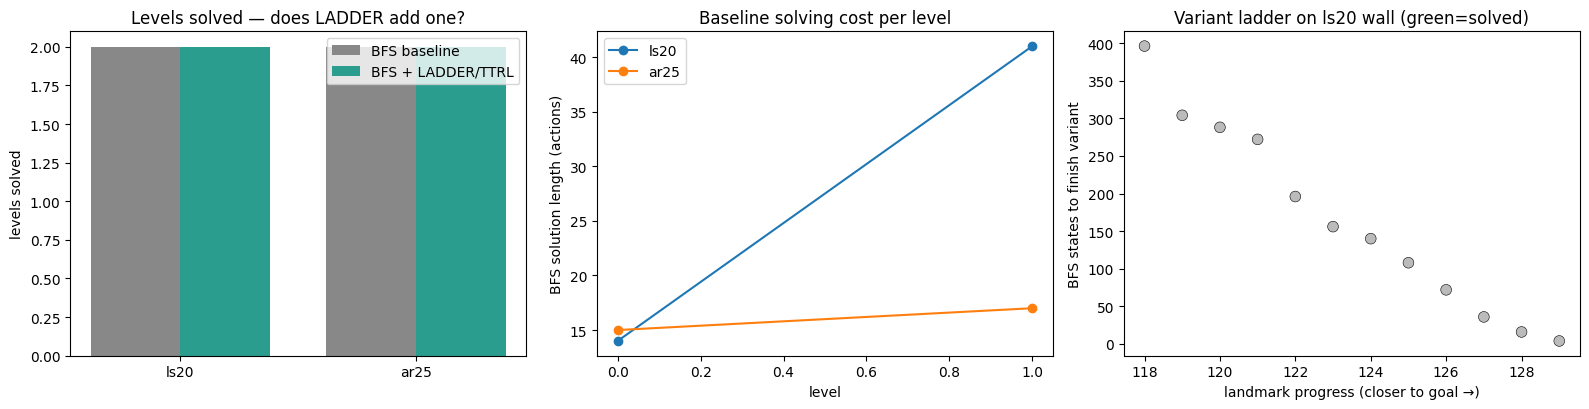

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) levels solved: BFS vs BFS+LADDER
ax = axes[0]
gids = list(results.keys())
bfs_n    = [len(results[g]["baseline"]["solved"]) for g in gids]
ladder_n = [bfs_n[i] + (1 if results[gids[i]]["ladder"]["cracked"] else 0) for i in range(len(gids))]
x = np.arange(len(gids)); w = 0.38
ax.bar(x - w/2, bfs_n, w, label="BFS baseline", color="#888")
ax.bar(x + w/2, ladder_n, w, label="BFS + LADDER/TTRL", color="#2a9d8f")
for i in range(len(gids)):
    if ladder_n[i] > bfs_n[i]:
        ax.text(x[i] + w/2, ladder_n[i] + 0.05, "+1 ✅", ha="center", color="#2a9d8f", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(gids); ax.set_ylabel("levels solved")
ax.set_title("Levels solved — does LADDER add one?"); ax.legend()

# (b) per-level BFS actions (the solving cost curve)
ax = axes[1]
for g in gids:
    pl = results[g]["baseline"]["per_level"]
    lv = sorted(k for k in pl if pl[k]["solved"])
    ax.plot(lv, [pl[k]["actions"] for k in lv], "o-", label=g)
ax.set_xlabel("level"); ax.set_ylabel("BFS solution length (actions)")
ax.set_title("Baseline solving cost per level"); ax.legend()

# (c) variant difficulty gradient on the first wall we tried
ax = axes[2]
plotted = False
for g in gids:
    info = results[g]["ladder"].get("info")
    if info and info.get("log"):
        prog = [r["landmark_progress"] for r in info["log"]]
        st   = [r["bfs_states"] for r in info["log"]]
        found= [r["suffix_found"] for r in info["log"]]
        colors = ["#2a9d8f" if f else "#bbb" for f in found]
        ax.scatter(prog, st, c=colors, s=60, edgecolor="k", linewidth=0.4)
        ax.set_xlabel("landmark progress (closer to goal →)")
        ax.set_ylabel("BFS states to finish variant")
        ax.set_title(f"Variant ladder on {g} wall (green=solved)")
        plotted = True
        break
if not plotted:
    ax.text(0.5, 0.5, "no variant log\n(no wall reached)", ha="center", va="center")
    ax.set_axis_off()

plt.tight_layout(); plt.show()

## 7 · Verdict — how to read this (and what we already learned)

**Runtime:** the full run is ~30–60 min on CPU (baseline BFS dominates). It only touches
the forked simulator — **zero scored actions** — so under Kaggle/RHAE this entire
adaptation is free; that's what makes TTRL viable here.

**Three outcomes, all informative:**

1. **`LADDER CRACKED ✅ L<wall>`** the BFS baseline could not clear → **the lever is real**.
   Re-rooting decomposed a level flat search couldn't reach, verified on a fresh engine.
   Green-light **Stage 1** (offline LADDER training, a *state-conditioned* policy, full
   GRPO) and **Stage 2** (TTRL behind BFS in `combined_agent`).

2. **`did NOT crack`** → still a real result, and the *expected* one for a cheap generator:
   the mature v13 BFS ladder is already near-optimal on the levels it can reach, so beating
   it needs a *better proposer of variants*, not more search. Try raising `GE_ITERS`,
   `VARIANT_BUDGET`, `N_VARIANTS` first.

3. **What the smoke tests already showed (be honest about it):** random re-rooting yields
   *deep-but-off-path* landmarks, and the Go-Explore archive **collapses** on `ls20`
   because the colour histogram barely moves as the player walks — so neither
   full-frame novelty (too fine, counts wander) nor histogram (too coarse) is a usable
   **progress signal without a learned value**. That is precisely LADDER's own finding —
   *"RL without [good] variants fails"* — and it pinpoints the real lever:

   > **The bottleneck is the variant/landmark *proposer*, which must be LEARNED.**
   > A state-conditioned GRPO policy/value (Stage 1) is the actual investment that closes
   > the 0.22 → 1.0+ gap — not re-rooting search tricks bolted onto BFS.

So this notebook's job is done either way: a crack validates the mechanism end-to-end; the
more likely "no crack" **localises the gap to the learned proposer**, telling us exactly
where Stage-1 compute should go. **No agent-code change until this is settled** — see
`LADDER_PLAN.md` §4.